In [14]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import io
import matplotlib.dates as mdates
import datetime
from netCDF4 import Dataset, num2date
import os
import pandas as pd
from scipy.ndimage import convolve
import glob
from mpl_toolkits.axes_grid1 import make_axes_locatable
import matplotlib as mpl

In [15]:
colores = {
   0: '#C72A66',     # Frambuesa oscuro (test-model_082337)
   1: '#B16A3C',      # Bronce / Marrón cobrizo (test-model_080952)
   2: '#1E8675',   # Verde azulado / Teal (test-model_060949)
   3: "#7D1485"  # Fucsia vibrante (test-model_051324)
}

DATOS LINDENBERG

In [16]:
df = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\semana_lindenberg\resultados_231757\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df.columns = df.columns.str.strip()

# real = df['Real (m)']
# predicho = df['Predicho (m)']
# error = df['Error (m)']
nombre=df['Nombre de Imagen']

#Separo la información del nombre de la imagen en días y horas
partes_nombre = nombre.str.split('_', expand=True)

fecha = partes_nombre[1]        # '20240224'
tiempo_ext = partes_nombre[2]   # '2034.jpg'

# Quitamos el .jpg
tiempo = tiempo_ext.str.replace('.jpg', '', regex=False) # Divide según el punto y el .jpg lo sustituye por texto en blanco

df['Fecha_Completa'] = pd.to_datetime(fecha + tiempo, format='%Y%m%d%H%M')
df = df.sort_values(by='Fecha_Completa')


In [17]:
df_vall = pd.read_csv(r'C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\semana_valladolid\resultados_231757\predicciones_detalladas.txt', sep=r'\s*\|\s*', engine='python', skiprows=[1])

df_vall.columns = df_vall.columns.str.strip()

# real = df_vall['Real (m)']
# predicho = df_vall['Predicho (m)']
# error = df_vall['Error (m)']
nombre=df_vall['Nombre de Imagen']

#Separo la información del nombre de la imagen en días y horas
partes_nombre = nombre.str.split('_', expand=True)

fecha = partes_nombre[1]        # '20240224'
tiempo_ext = partes_nombre[2]   # '2034.jpg'

# Quitamos el .jpg
tiempo = tiempo_ext.str.replace('.jpg', '', regex=False) # Divide según el punto y el .jpg lo sustituye por texto en blanco

df_vall['Fecha_Completa'] = pd.to_datetime(fecha + tiempo, format='%Y%m%d%H%M')
df_vall = df_vall.sort_values(by='Fecha_Completa')

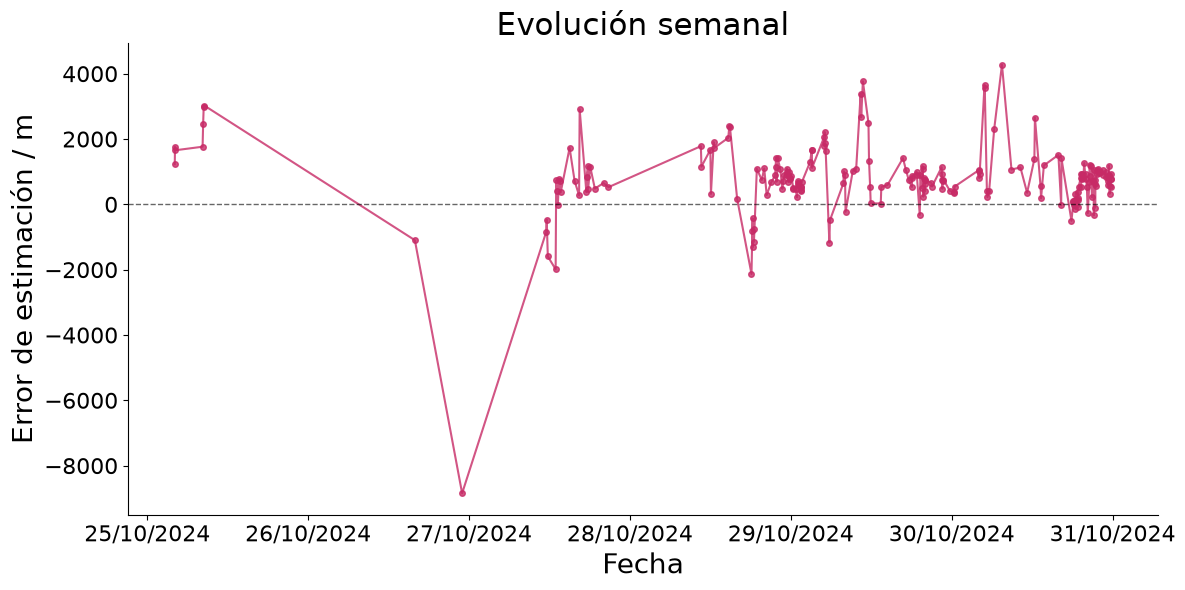

In [18]:
fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df['Fecha_Completa'], df['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

#formato_fecha = mdates.DateFormatter('%d/%m/%Y %H:%M')
formato_fecha = mdates.DateFormatter('%d/%m/%Y')
ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución semanal', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

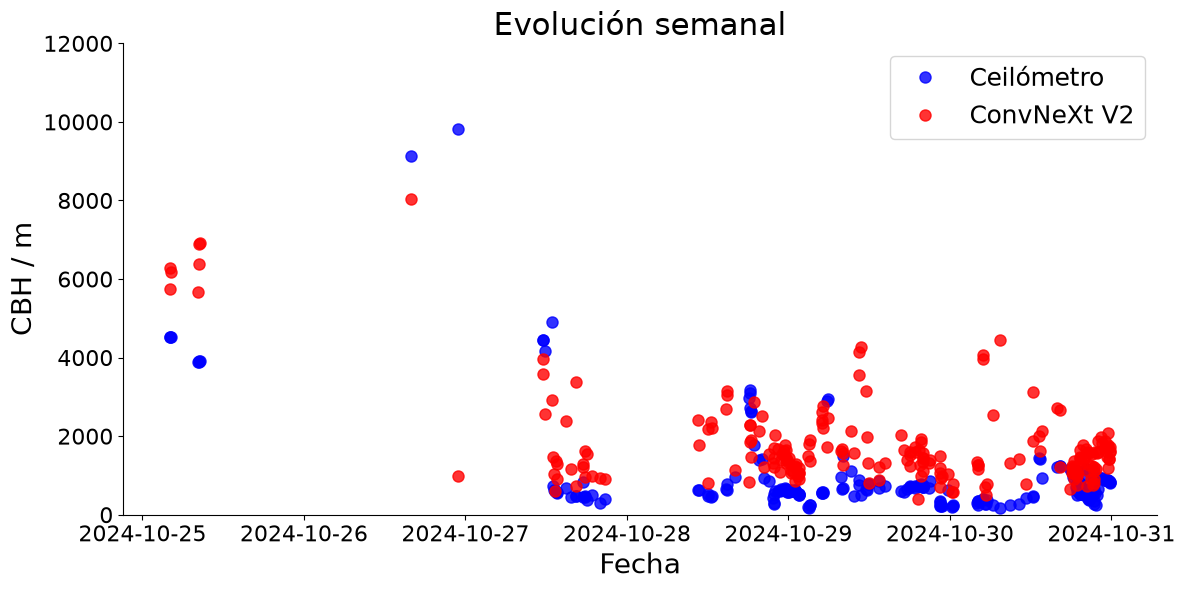

In [19]:
######### REPRESENTACIÓN SEMANA ##############

fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df['Fecha_Completa'], df['Real (m)'], color='blue', linestyle='none', marker='o', markersize=8, alpha=0.8, label='Ceilómetro')
ax.plot(df['Fecha_Completa'], df['Predicho (m)'], color='red', linestyle='none', marker='o', markersize=8, alpha=0.8, label='ConvNeXt V2')

# Línea de referencia en los límites de cada tipo de nube
# ax.axhline(2000, color='black', linestyle='--', linewidth=1, alpha=0.6)
# ax.axhline(6000, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('CBH / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)
plt.ylim(0,12000)
# formato_fecha = mdates.DateFormatter('%H:%M')

# ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.title('Evolución semanal', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

Diagrama paridad

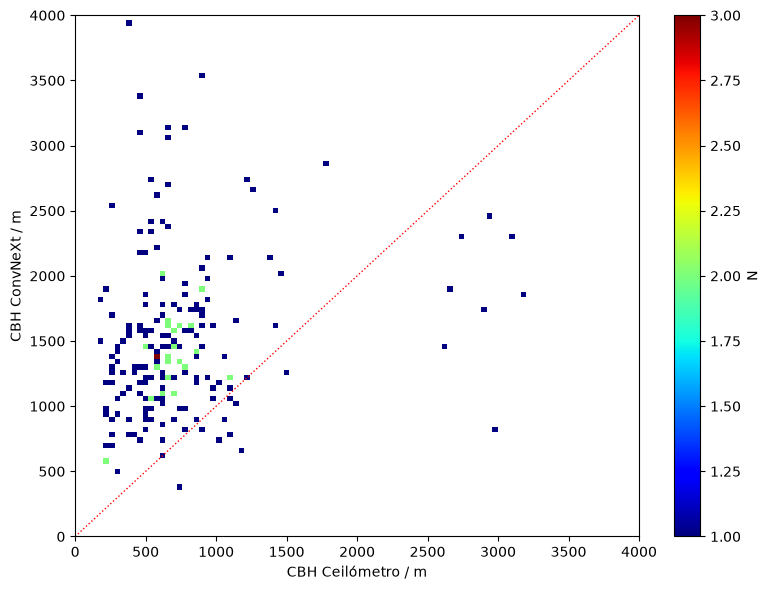

In [20]:
def plot_scatter(df_global: pd.DataFrame, limite_max: int = 15000):

    plt.figure(figsize=(8, 6))
    
    # Scatterplot con histograma 2D (escala lineal)
    h1 = plt.hist2d(df_global['Real (m)'], df_global['Predicho (m)'], 
                    bins=100, range=[[0, limite_max], [0, limite_max]], 
                    cmap='jet', cmin=1) 
    
    plt.colorbar(h1[3], label='N') 
    
    # Línea 1:1
    plt.plot([0, limite_max], [0, limite_max], 'r:', linewidth=1)
    
    # Etiquetas de los ejes
    plt.xlabel("CBH Ceilómetro / m")
    plt.ylabel("CBH ConvNeXt / m")

    plt.tight_layout()
    plt.show()

plot_scatter(df, 4000)

Seleccionamos un solo día

In [21]:
datos_por_dia = df['Fecha_Completa'].dt.date.value_counts().sort_index()

print("Número de datos por día:")
print(datos_por_dia)

Número de datos por día:
Fecha_Completa
2024-10-25     7
2024-10-26     2
2024-10-27    22
2024-10-28    38
2024-10-29    68
2024-10-30    83
Name: count, dtype: int64


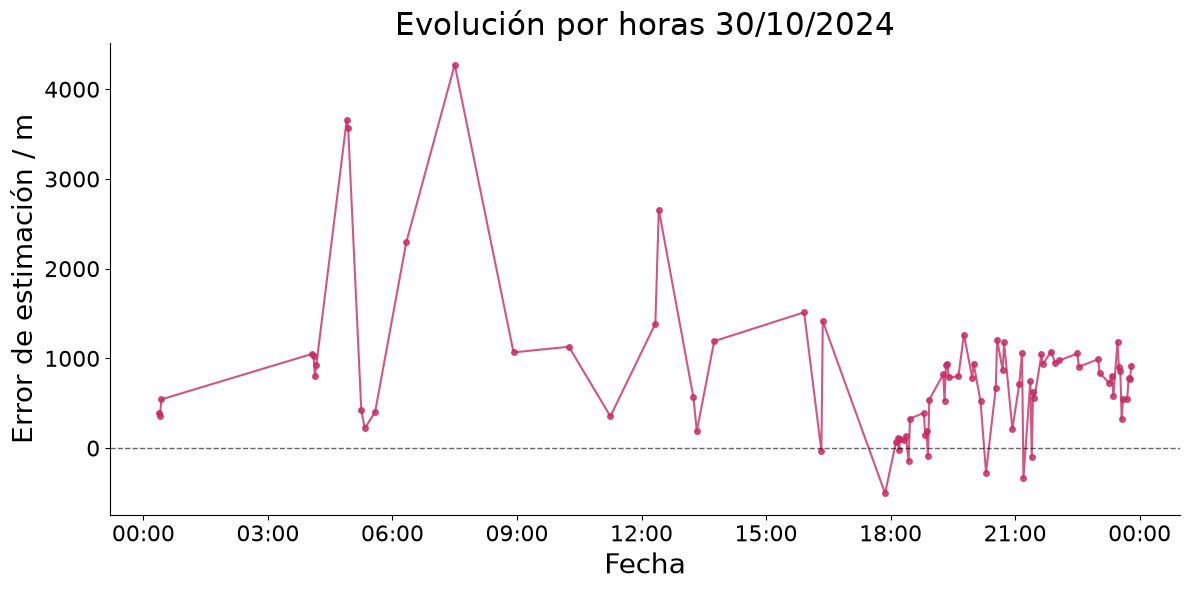

In [22]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2024, 10, 30)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Error (m)'], color='#C72A66', marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8)
# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas 30/10/2024', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

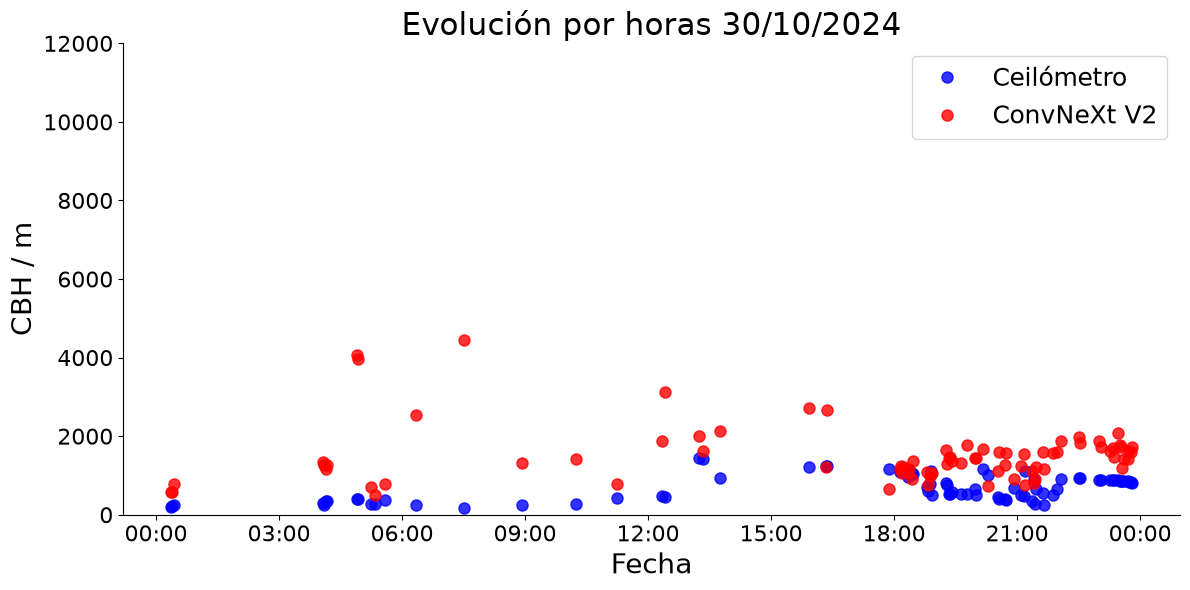

In [23]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dia = datetime.date(2024, 10, 30)

# Nuevo data frame
df_dia = df[df['Fecha_Completa'].dt.date == dia]


fig, ax = plt.subplots(figsize=(12, 6))


ax.plot(df_dia['Fecha_Completa'], df_dia['Real (m)'], color='blue', linestyle='none', marker='o', markersize=8, alpha=0.8, label='Ceilómetro')
ax.plot(df_dia['Fecha_Completa'], df_dia['Predicho (m)'], color='red', linestyle='none', marker='o', markersize=8, alpha=0.8, label='ConvNeXt V2')

# Línea de referencia en los límites de cada tipo de nube
# ax.axhline(2000, color='black', linestyle='--', linewidth=1, alpha=0.6)
# ax.axhline(6000, color='black', linestyle='--', linewidth=1, alpha=0.6)

plt.ylim(0,12000)

ax.set_ylabel('CBH / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.legend(fontsize=18, loc='upper right')
plt.title('Evolución por horas 30/10/2024', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

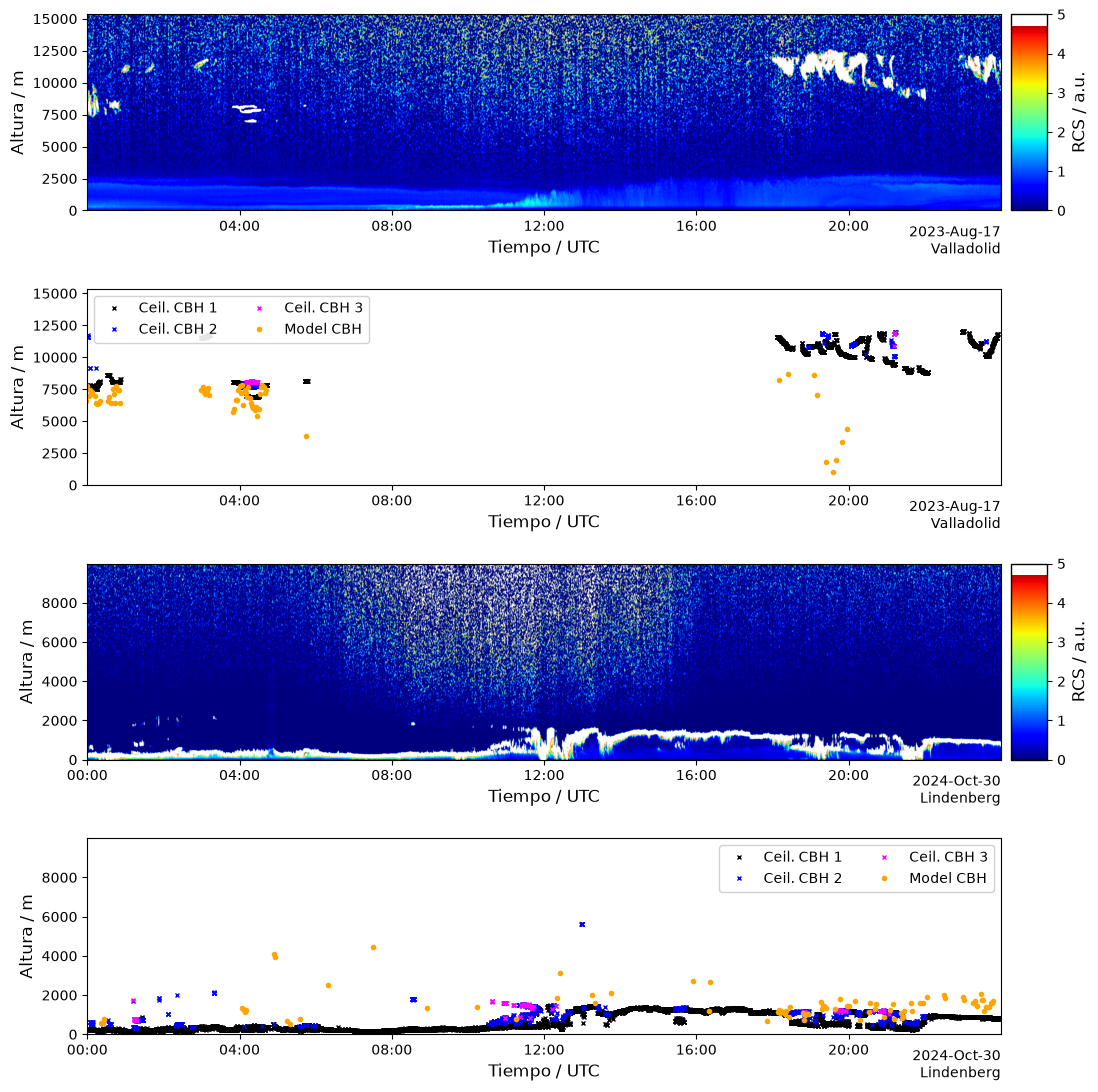

In [79]:
def plot_panel(ax, in_file, place, mode='rcs', df=None):
    # Leer variables del nc
    ds = Dataset(in_file)
    keys = ds.variables.keys()
    var_beta = next((s for s in ['beta_raw', 'beta_att', 'beta', 'rcs'] if s in keys), None)

    if var_beta is None:
        ds.close()
        print("No se encontró la variable de retrodispersión (beta/rcs).")
        return

    y_raw = np.array(ds['range'][:])
    beta = np.array(ds[var_beta][:], dtype='f')
    alt_var = 'altitude' if 'altitude' in keys else 'alt'
    
    # Ojo para cambiar a nivel del mar (si fuera necesario)
    # altitud_estacion = ds.variables[alt_var].getValue() / 1000

    time_var = ds.variables['time']
    time_dt_raw = num2date(time_var[:], time_var.units)
    time_dt = [datetime.datetime(t.year, t.month, t.day, t.hour, t.minute, t.second) for t in time_dt_raw]
    x = mdates.date2num(time_dt)
    fecha_str = time_dt[0].strftime('%Y-%b-%d')
    y = (y_raw) # Lo pongo en metros


    # PANEL QUICKLOOK (RCS)

    if mode == 'rcs':
        # Ajuste de ruido
        Z = beta * 1e6 if np.nanmax(beta) < 0.001 else beta / 1e5
        filtroA = np.ones((110 // 15, 9), dtype=np.float32)
        filtroA /= np.sum(filtroA)
        media = convolve(Z, filtroA, mode='constant', cval=0)
        Z = media.T

        # Poner un tope blanco a la barra de color
        try:
            base_cmap = mpl.colormaps['jet']
        except AttributeError:
            import matplotlib.cm as cm
            base_cmap = cm.get_cmap('jet')

        # Creamos una lista de 256 colores
        n_colors = 256
        color_list = base_cmap(np.linspace(0, 1, n_colors))

        # Forzamos que los últimos 15 niveles sean blanco
        color_list[-15:] = [1, 1, 1, 1]

        new_cmap = mpl.colors.ListedColormap(color_list)
        new_cmap.set_over('white')

        im = ax.imshow(Z, extent=[min(x), max(x), min(y), max(y)],
                       aspect='auto', origin='lower', cmap=new_cmap)
        im.set_clim(0, 5)

        divider = make_axes_locatable(ax)
        cax = divider.append_axes("right", size="4%", pad=0.1) 

        cb = plt.colorbar(im, cax=cax, label='RCS / a.u.')
        cb.outline.set_edgecolor('black')
        cb.outline.set_linewidth(1)
        cb.ax.yaxis.label.set_fontsize(12)
        cb.ax.tick_params(labelsize=10)

        # ax.text(0.005, 0.98, label_abc, transform=ax.transAxes,
        #         fontsize=14, fontweight='bold', color='white', va='top', ha='left')


    # PANEL PUNTOS (3 Capas CBH)

    elif mode == 'cbh':
        ax.set_facecolor('white')
        ax.set_xlim(min(x), max(x))
        # ax.text(0.005, 0.98, label_abc, transform=ax.transAxes,
        #         fontsize=14, fontweight='bold', color='black', va='top', ha='left')

        if 'cbh' in ds.variables:
            cbh_raw = ds.variables['cbh'][:]
            cbh = cbh_raw 
            
            # Definir colores y etiquetas para hasta 3 capas
            colores = ['black', 'blue', 'magenta']
            etiquetas = ['Ceil. CBH 1', 'Ceil. CBH 2', 'Ceil. CBH 3']
            
            # Si el array es 2D
            if cbh.ndim > 1:
                n_capas = min(cbh.shape[1], 3) # Nos aseguramos de sacar máximo 3
                for i in range(n_capas):
                    cbh_capa = cbh[:, i]
                    ax.plot(x, np.where(cbh_capa > 0, cbh_capa, np.nan), 'x',
                            color=colores[i], markersize=3, label=etiquetas[i])
            else:
                # Por si acaso el netcdf viene con cbh en 1D
                ax.plot(x, np.where(cbh > 0, cbh, np.nan), 'x',
                        color=colores[0], markersize=3, label=etiquetas[0])

            if df is not None and 'Fecha_Completa' in df.columns and 'Predicho (m)' in df.columns:
                ax.plot(df['Fecha_Completa'], df['Predicho (m)'], color='orange', linestyle='none', marker='o', markersize=3, label='Model CBH')
            
        if place=="Lindenberg":
            ax.legend(loc='upper right', ncol=2, fontsize=10, framealpha=0.9)
        else:
            ax.legend(loc='upper left', ncol=2, fontsize=10, framealpha=0.9)
        
        
        # Crear un eje invisible del mismo tamaño (4%) que el RCS para que cuadren a lo ancho
        divider = make_axes_locatable(ax)
        cax_invisible = divider.append_axes("right", size="4%", pad=0.1)
        cax_invisible.axis('off')

    # Configuraciones comunes a ambos ejes
    ax.set_ylabel('Altura / m', fontsize=12)
    ax.set_ylim(0, max(y))
    ax.xaxis.set_major_locator(mdates.HourLocator(interval=4))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
    ax.tick_params(axis='x', labelsize=10)
    ax.tick_params(axis='y', labelsize=10)

    # Poner la fecha abajo a la derecha fuera del eje
    ax.annotate(f'{fecha_str}\n{place}', xy=(1, 0), xycoords='axes fraction',
                xytext=(0, -10), textcoords='offset points',
                ha='right', va='top', fontsize=10)

    ds.close()


def main():
    # Rutas
    input_linden = r"C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\archivos_nc\lindenberg"
    input_vall = r"C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\archivos_nc\valladolid"

  
    fecha_linden = "20241030"  # O "20250518", etc.
    fecha_vall= "20230817"

    # Buscar el archivo correspondiente a esa fecha
    files_linden = glob.glob(os.path.join(input_linden, f"*{fecha_linden}*.nc"))
    
    if not files_linden:
        print(f"Error: No se ha encontrado ningún archivo para la fecha {fecha_linden} en la carpeta indicada.")
        return
    
    archivo_nc_linden = files_linden[0]

    # Buscar el archivo correspondiente a esa fecha
    files_vall = glob.glob(os.path.join(input_vall, f"*{fecha_vall}*.nc"))
        
    if not files_vall:
        print(f"Error: No se ha encontrado ningún archivo para la fecha {fecha_vall} en la carpeta indicada.")
        return
    
    archivo_nc_vall = files_vall[0]


    # ## PRIMERA GRÁFICA
    # fig1, ax1 = plt.subplots(figsize=(10, 4)) 
    
    # plot_panel(ax1, archivo_nc, " ", mode='rcs')
    # ax1.set_xlabel('Tiempo / UTC', fontsize=10)
    # fig1.tight_layout() 
    

    # ## SEGUNDA GRÁFICA
    # fig2, ax2 = plt.subplots(figsize=(10, 4))
    
    # plot_panel(ax2, archivo_nc, " ", mode='cbh', df=df)
    # ax2.set_xlabel('Tiempo / UTC', fontsize=10)
    # fig2.tight_layout()

    # plt.show()



    fig, axes = plt.subplots(4, 1, figsize=(12,12))
    plt.subplots_adjust(hspace=0.4, left=0.1, right=0.9, bottom=0.1, top=0.95)

    plot_panel(axes[0], archivo_nc_vall, "Valladolid", mode='rcs', )
    plot_panel(axes[1], archivo_nc_vall, "Valladolid", mode='cbh', df=df_vall)

    plot_panel(axes[2], archivo_nc_linden, "Lindenberg", mode='rcs', )
    plot_panel(axes[3], archivo_nc_linden, "Lindenberg", mode='cbh', df=df)

    axes[0].set_xlabel('Tiempo / UTC', fontsize=12)
    axes[1].set_xlabel('Tiempo / UTC', fontsize=12)
    axes[2].set_xlabel('Tiempo / UTC', fontsize=12)
    axes[3].set_xlabel('Tiempo / UTC', fontsize=12)

    plt.show()

main()

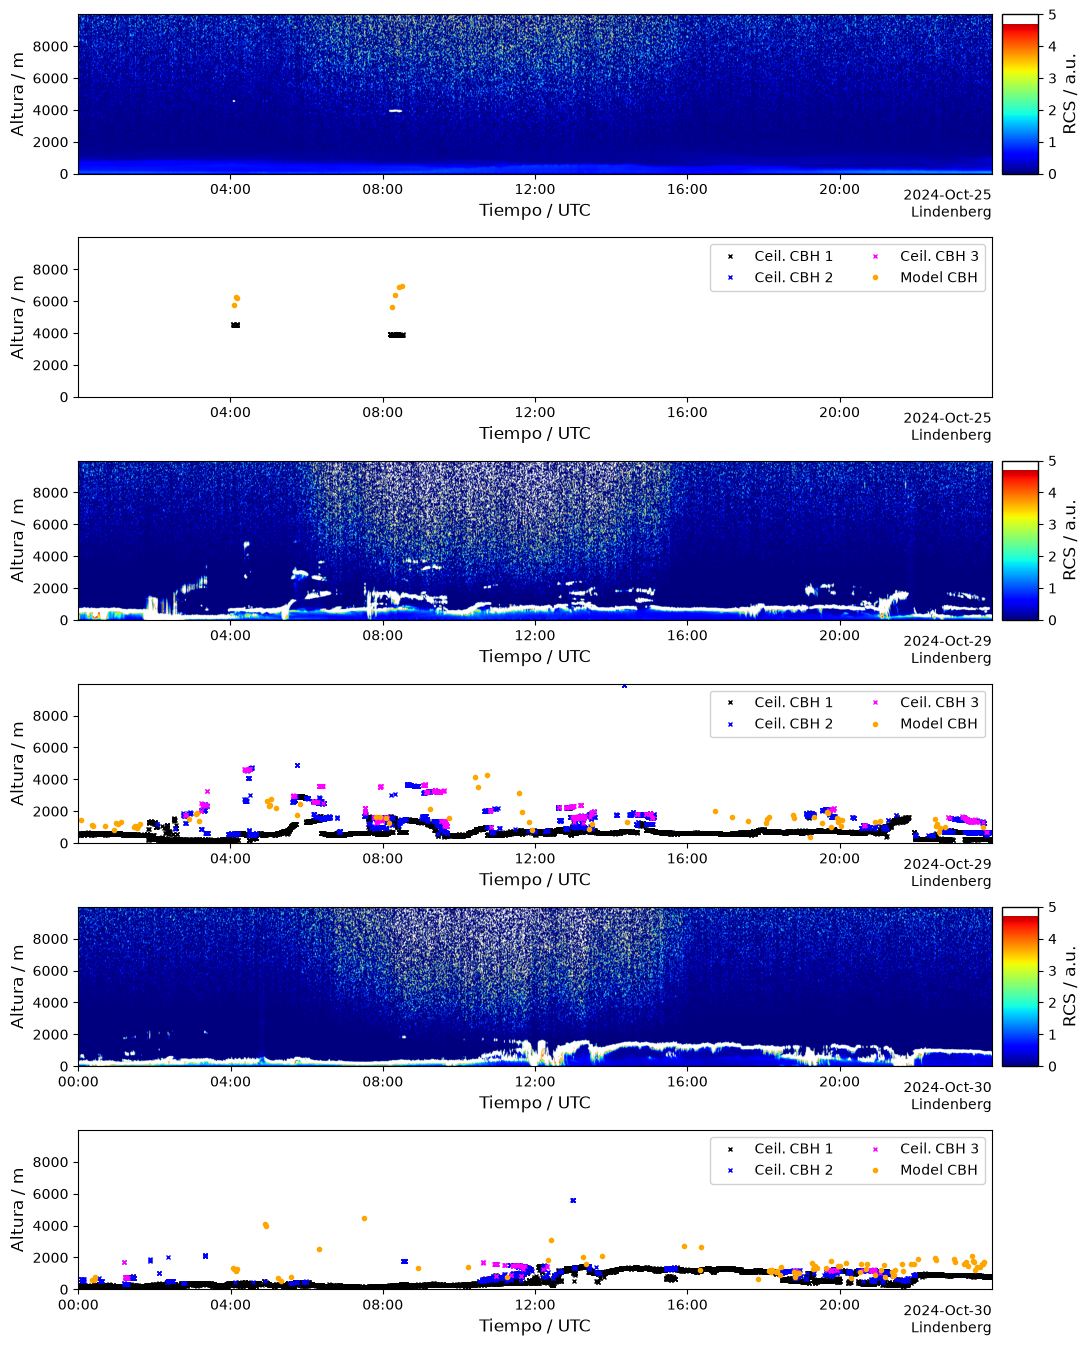

In [90]:
def main_lin():
    # Rutas
    input = r"C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\archivos_nc\lindenberg"

  
    fechas = ['20241025', '20241029', '20241030'] # O "20250518", etc.
    # fechas = [ '20241029', '20241030'] # O "20250518", etc.

    fig, axes = plt.subplots(2*len(fechas), 1, figsize=(12,15))
    plt.subplots_adjust(hspace=0.4, left=0.1, right=0.9, bottom=0.1, top=0.95)

    # Buscar el archivo correspondiente a esa fecha
    for i in range(len(fechas)):

        files = glob.glob(os.path.join(input, f"*{fechas[i]}*.nc"))
        
        if not files:
            print(f"Error: No se ha encontrado ningún archivo para la fecha {fechas[i]} en la carpeta indicada.")
            return
        
        archivo_nc = files[0]

        plot_panel(axes[2*i], archivo_nc, "Lindenberg", mode='rcs', )
        plot_panel(axes[2*i+1], archivo_nc, "Lindenberg", mode='cbh', df=df)

        axes[2*i].set_xlabel('Tiempo / UTC', fontsize=12)
        axes[2*i+1].set_xlabel('Tiempo / UTC', fontsize=12)



    plt.show()

main_lin()

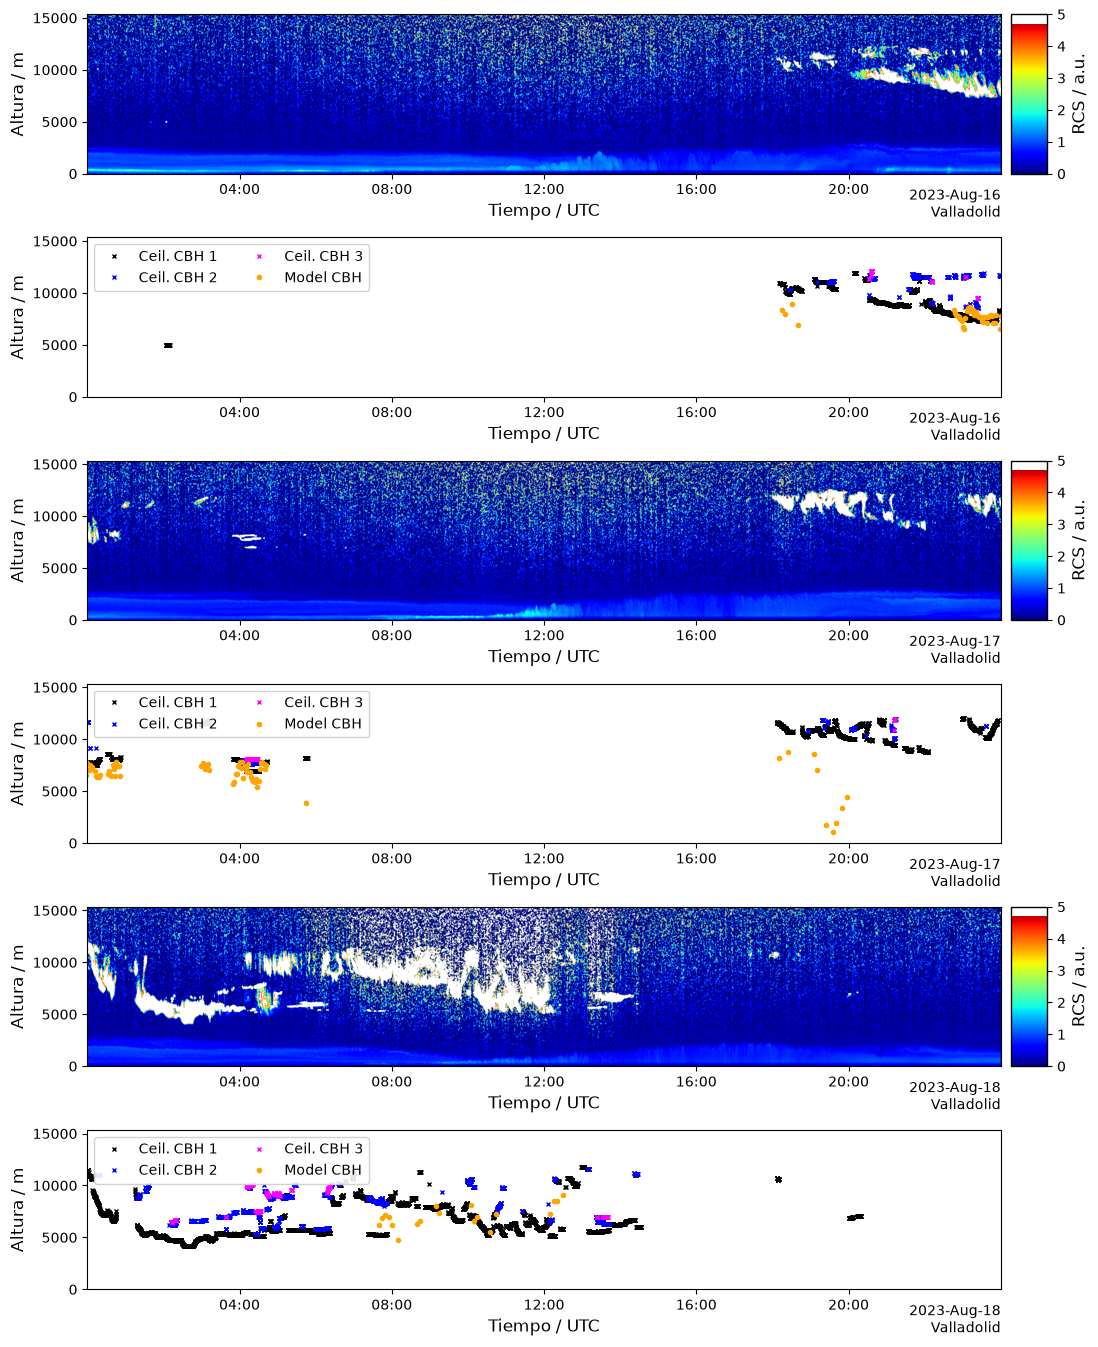

In [95]:
def main_vall():
    # Rutas
    input = r"C:\Users\USUARIO\Documents\TFG_ALTURA\evolucion_predicciones\archivos_nc\valladolid"

  
    #fechas = ['20230812', '20230813', '20230814'] # O "20250518", etc.
    fechas = ['20230816', '20230817', '20230818'] # O "20250518", etc.

    # fechas = ['20230814','20230817'] # O "20250518", etc.

    fig, axes = plt.subplots(6, 1, figsize=(12,15))
    plt.subplots_adjust(hspace=0.4, left=0.1, right=0.9, bottom=0.1, top=0.95)

    # Buscar el archivo correspondiente a esa fecha
    for i in range((len(fechas))):

        files = glob.glob(os.path.join(input, f"*{fechas[i]}*.nc"))
        
        if not files:
            print(f"Error: No se ha encontrado ningún archivo para la fecha {fechas[i]} en la carpeta indicada.")
            return
        
        archivo_nc = files[0]

        plot_panel(axes[2*i], archivo_nc, "Valladolid", mode='rcs', )
        plot_panel(axes[2*i+1], archivo_nc, "Valladolid", mode='cbh', df=df_vall)

        axes[2*i].set_xlabel('Tiempo / UTC', fontsize=12)
        axes[2*i+1].set_xlabel('Tiempo / UTC', fontsize=12)


    plt.show()

main_vall()

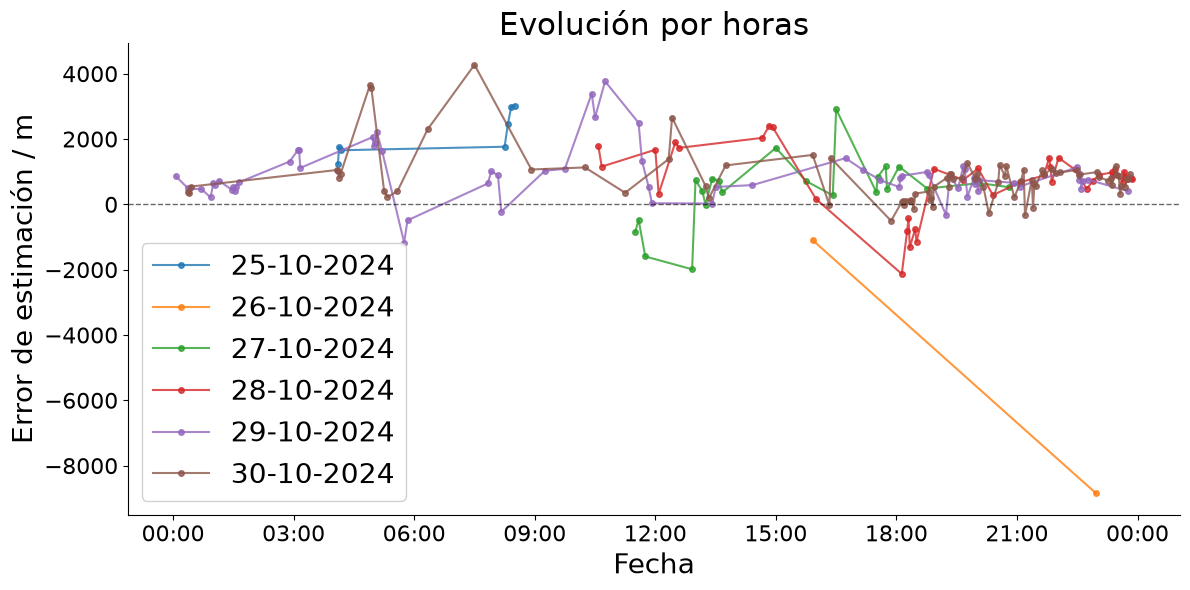

In [10]:
######### REPRESENTACIÓN DE UN SOLO DÍA ##############

dias = df['Fecha_Completa'].dt.date.sort_index()
lista_dias = sorted(list(set(dias)))

fig, ax = plt.subplots(figsize=(12, 6))

for dia in lista_dias:
    # if dia == datetime.date(2024,10,26):
    #     continue
    # Nuevo data frame
    df_dia = df[df['Fecha_Completa'].dt.date == dia]
    fecha_auxiliar = pd.to_datetime(df_dia['Fecha_Completa'].dt.strftime('2000-01-01 %H:%M:%S')) #ponemos a todos los días la misma fecha para que colapsen en el plot
    ax.plot(fecha_auxiliar, df_dia['Error (m)'], marker='o', markersize=4, linestyle='-', linewidth=1.5, alpha=0.8, label=f'{dia.day}-{dia.month}-{dia.year}')



# Línea de referencia en el 0
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)


ax.set_ylabel('Error de estimación / m', fontsize=20)
ax.set_xlabel('Fecha', fontsize=20)

formato_fecha = mdates.DateFormatter('%H:%M')

ax.xaxis.set_major_formatter(formato_fecha)

# Tamaño y rotación de los valores de los ejes
plt.xticks(rotation=0, fontsize=16)
plt.yticks(fontsize=16)
plt.title('Evolución por horas', fontsize=22)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.legend(loc='lower left', framealpha=0.9, facecolor='white', fontsize=20)

plt.tight_layout()
plt.show()